In [2]:
import requests
import numpy as np
import json
import pandas as pd
from datetime import datetime, timedelta
import sklearn
end_date = datetime(2024, 6, 1)
start_date = end_date - timedelta(days=6000)

In [3]:
API_KEY = "wUvM2M29ZVxHDvK8IRp2P7iyrT8uhQG4"

ticker = "AAPL"

url_hist_stock_price = f"https://financialmodelingprep.com/stable/historical-price-eod/light?symbol={ticker}&from={start_date.date()}&to={end_date.date()}&apikey={API_KEY}"

# Historical Data Request
response_hist_stock_price = requests.get(url_hist_stock_price)

json_response_hist_stock_price = response_hist_stock_price.json()

df_stock_hist = pd.DataFrame(json_response_hist_stock_price)

df_stock_hist['date'] = pd.to_datetime(df_stock_hist['date'])
df_stock_hist['price'] = df_stock_hist['price'].astype(float)
df_stock_hist['volume'] = df_stock_hist['volume'].astype(float)


df_stock_hist.set_index('date', inplace=True)
df_stock_hist.drop(columns=['symbol'])

closing_price = df_stock_hist[['price']]
i_volume = df_stock_hist[['volume']]
volume =i_volume.apply(np.log10)

In [4]:
# Daily Return
daily_return = closing_price.pct_change()
# 5-Day Return
ret_5d = closing_price.pct_change(5)
# 10-Day Return
ret_10d = closing_price.pct_change(10)

# 5-Day Volatility (Std Dev of Returns)
vol_5d = closing_price.pct_change().rolling(window=5).std()

# 10-Day Volatility
vol_10d = (closing_price.pct_change().rolling(window=10).std())

# Momentum (10d)
momentum_10d = closing_price - closing_price.shift(10)

# SMA_10/SMA_50 Ratio
sma_10 = closing_price.rolling(window=10).mean()
sma_50 = closing_price.rolling(window=50).mean()
sma_ratio = sma_10/sma_50

# Z-score (20d)
rolling_mean = closing_price.rolling(window=20).mean()
rolling_std = closing_price.rolling(window=20).std()
z_score_20d = (closing_price - rolling_mean)/rolling_std

# RSI (14d)
delta = closing_price.diff()
gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain/avg_loss
rsi_14 = 100 - (100 / (1 + rs))

y = closing_price.pct_change(-30)

avrg = y.mean()

y.columns = ['y']


dataframes = [
    (daily_return, 'ret_1d'),
    (ret_5d, 'ret_5d'),
    (ret_10d, 'ret_10d'),
    (vol_5d, 'vol_5d'),
    (vol_10d, 'vol_10d'),
    (momentum_10d, 'momentum_10d'),
    (sma_ratio, 'sma_ratio_10_50'),
    (z_score_20d, 'zscore_20d'),
    (rsi_14, 'rsi_14'),
    (volume,'volume'),
    (y,'y'),
]

df_features_short_term = pd.concat(
    [df.rename(columns={df.columns[0]: name}) for df, name in dataframes],
    axis=1
).dropna()



In [26]:
print(y.max())

y    0.464646
dtype: float64


              ret_1d    ret_5d   ret_10d    vol_5d   vol_10d  momentum_10d  \
date                                                                         
2024-03-21 -0.264766  0.161098  0.484755 -0.167611 -0.823095      0.820981   
2024-03-20  2.896627  1.085230  1.506309  1.183020  0.143810      3.595602   
2024-03-19 -0.873136  1.278652  1.069294  0.958007  0.334157      2.418281   
2024-03-18 -0.800968  0.671626  0.876946  1.217946  0.438267      1.884701   
2024-03-15 -0.334090  0.237649  0.584731  1.239684  0.463095      1.096378   
...              ...       ...       ...       ...       ...           ...   
2008-03-13  0.814389 -0.988610 -1.999743  1.765103  1.847155      0.018889   
2008-03-12 -0.927364 -0.642062 -1.916832  1.550357  1.828771      0.029216   
2008-03-11  0.817635 -0.993540 -2.340608  1.143857  1.307623     -0.012093   
2008-02-29  1.753657  0.782766 -0.024621  1.111757  1.947385      0.184127   
2008-02-28  2.748782  2.348295  0.586541  1.462642  2.377935    

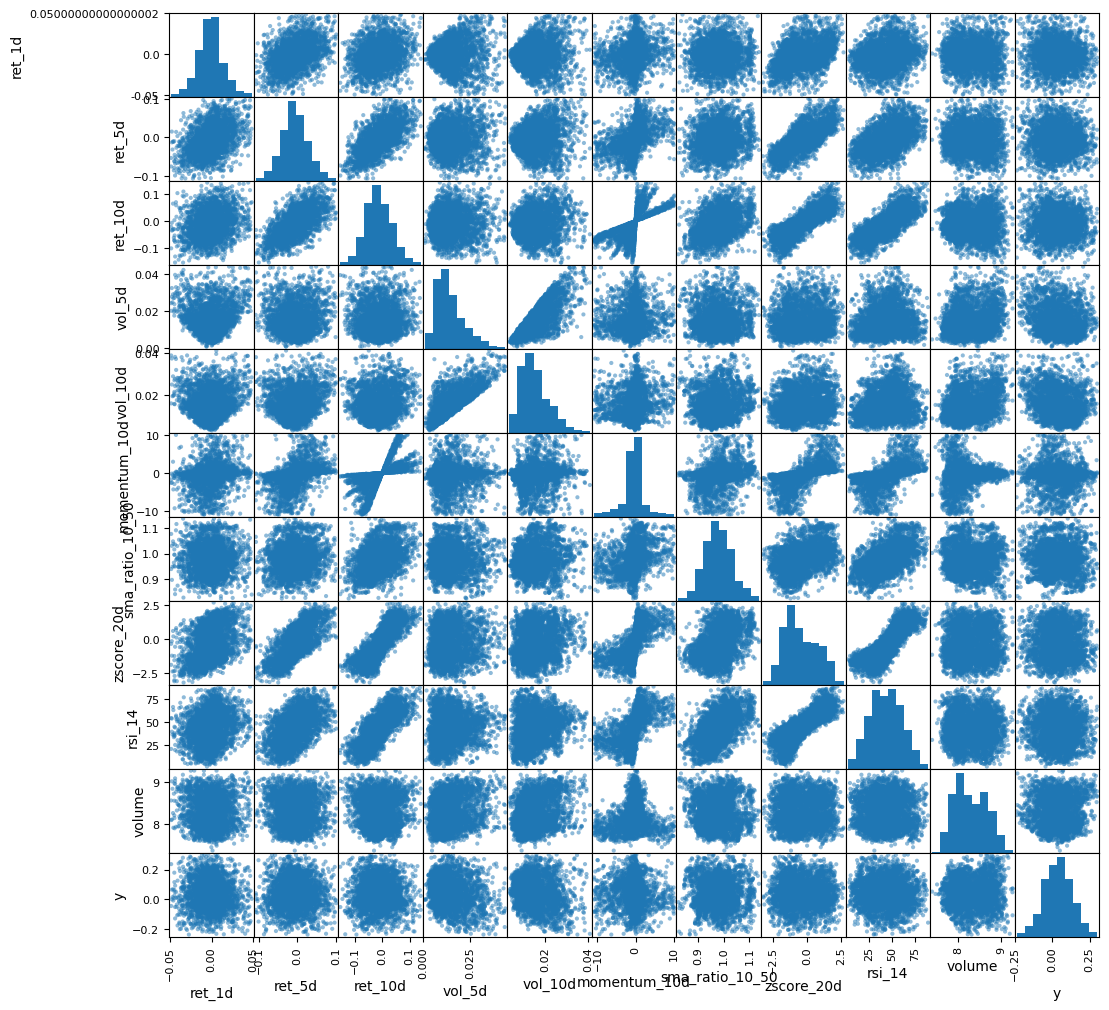

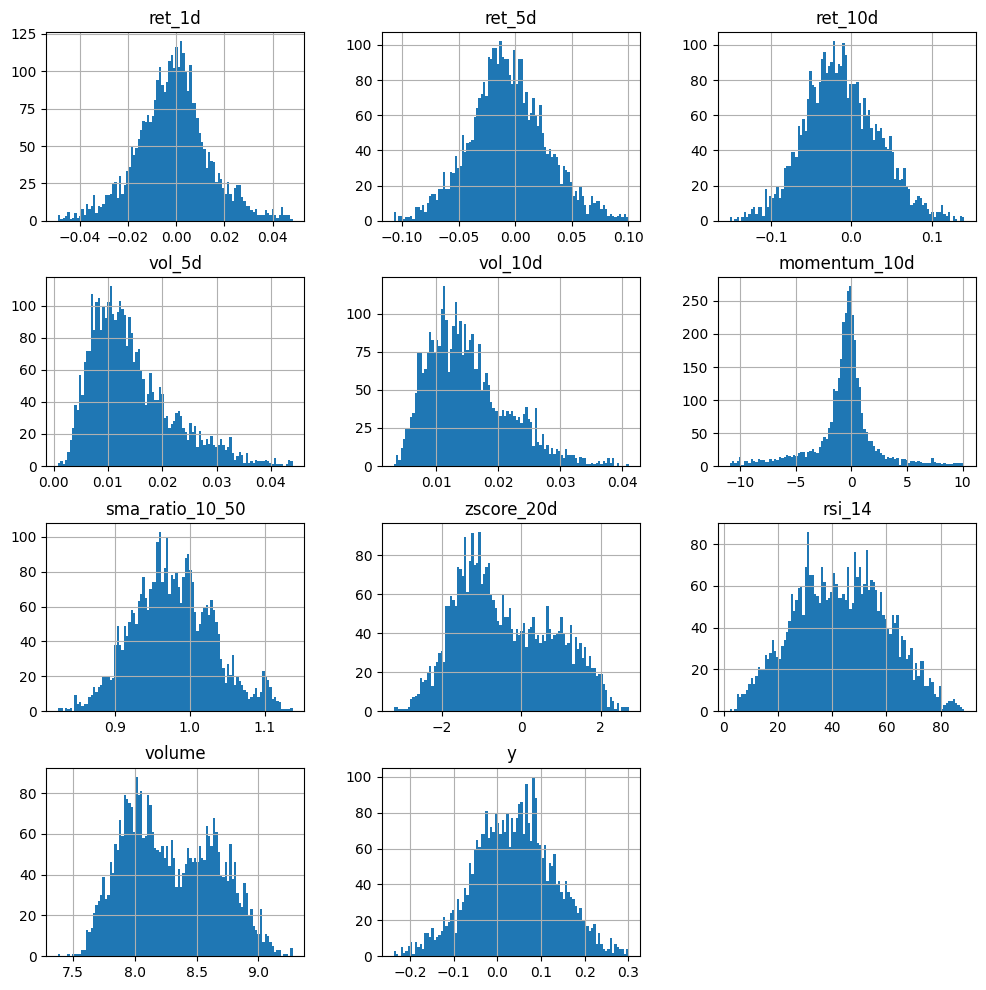

In [5]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

# Calculate Z-scores for the dataset
z_scores = np.abs(zscore(df_features_short_term))

# Set a threshold for identifying outliers (commonly 3)
threshold = 2.5 # confidence interval of data around 97.6 %.

# Identify rows where any column has a Z-score greater than threshold
outliers = (z_scores > threshold).any(axis=1)

# Remove outliers
df_no_outliers = df_features_short_term[~outliers]


# DATA ANALYSIS

from pandas.plotting import scatter_matrix

scatter_matrix(df_no_outliers, figsize=(12, 12), diagonal='hist')  # or 'kde'
df_no_outliers.hist(figsize=(12, 12), bins=100)

X_data = df_no_outliers.drop(columns=['y'])
y = df_no_outliers['y']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_data)
X_scaled = scaler.transform(X_data)
X = pd.DataFrame(X_scaled, index=X_data.index, columns=X_data.columns)
print(X)


In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error 

from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# Sample time series data
# Split data between test set and train

import pandas as pd

# Ensure Date column is datetime type and sort the data
def train_test_split(df, ratio=0.2):

    num_instances = df.shape[0]

    split_index = int(num_instances * (1 - ratio))
    train_df = df.iloc[:split_index]
    test_df = df.iloc[split_index:]
    return (train_df,test_df)

X_train, X_test = train_test_split(X)
y_train, y_test = train_test_split(y)



# Use Kfold validation to tune hyperparameters using the train dataset
X_train_arr = X_train.values
y_train_arr = y_train.values

tscv = TimeSeriesSplit(n_splits=5)

val_rmse_scores = []
for i, (train_index, val_index) in enumerate(tscv.split(X_train_arr)):
    print(f"Split {i+1}: Train {len(train_index)}, Test {len(val_index)}")

    X_train_i, X_val_i = X_train_arr[train_index], X_train_arr[val_index]
    y_train_i, y_val_i = y_train_arr[train_index], y_train_arr[val_index]

    model = xgb.XGBRegressor(n_estimators=1000, 
                             early_stopping_rounds=50, 
                             learning_rate=0.01)

    model.fit(
        X_train_i, y_train_i,
        eval_set=[(X_train_i,y_train_i),(X_val_i, y_val_i)],
        verbose=100
    )
    
    preds = model.predict(X_val_i)
    rmse = root_mean_squared_error(y_val_i, preds)
    val_rmse_scores.append(rmse)

# Have a metric for directional accuracy to evaluate the impact of different hyperparameters
print(val_rmse_scores)
final_rmse = np.mean(val_rmse_scores)
print(f"\nFinal average RMSE across all folds: {final_rmse:.4f}")



model = xgb.XGBRegressor(n_estimators=1000,early_stopping_rounds=50,learning_rate=0.01)

model.fit(X_train,y_train,eval_set=[(X_test,y_test)],verbose=100) # not sure about this

final_pred = model.predict(X_test)

print(root_mean_squared_error(y_test, final_pred))


Split 1: Train 472, Test 470
[0]	validation_0-rmse:0.08977	validation_1-rmse:0.10835
[50]	validation_0-rmse:0.06787	validation_1-rmse:0.11286
Split 2: Train 942, Test 470
[0]	validation_0-rmse:0.09532	validation_1-rmse:0.09230
[50]	validation_0-rmse:0.07924	validation_1-rmse:0.09793
Split 3: Train 1412, Test 470
[0]	validation_0-rmse:0.09411	validation_1-rmse:0.08933
[100]	validation_0-rmse:0.07422	validation_1-rmse:0.08600
[200]	validation_0-rmse:0.06314	validation_1-rmse:0.08444
[298]	validation_0-rmse:0.05613	validation_1-rmse:0.08465
Split 4: Train 1882, Test 470
[0]	validation_0-rmse:0.09269	validation_1-rmse:0.07232
[50]	validation_0-rmse:0.08149	validation_1-rmse:0.07775
Split 5: Train 2352, Test 470
[0]	validation_0-rmse:0.08893	validation_1-rmse:0.10915
[100]	validation_0-rmse:0.07307	validation_1-rmse:0.10894
[102]	validation_0-rmse:0.07287	validation_1-rmse:0.10897
[0.1083450981522814, 0.09230204510426283, 0.08435110593833774, 0.07232037123875537, 0.1081568804507852]

Final 

<Axes: title={'center': 'Feature Importance'}>

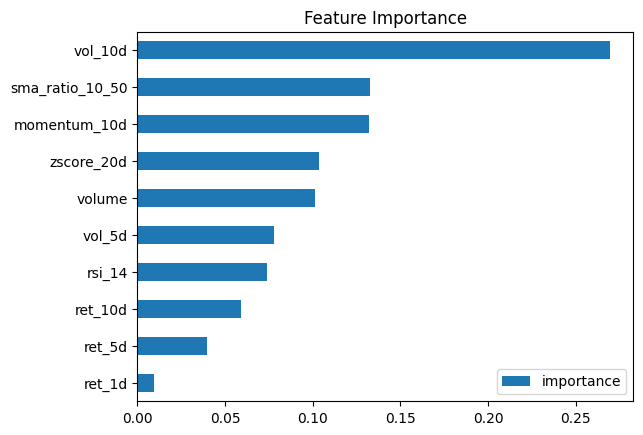

In [62]:
fi = pd.DataFrame(data = model.feature_importances_,index=model.feature_names_in_,columns=['importance'])
fi.sort_values('importance').plot(kind='barh',title='Feature Importance')


In [63]:
y_pred = model.predict(X_test)
pd.set_option('display.max_rows', None)
result = pd.DataFrame()
result['y'] = y_test
result['y_pred'] = y_pred
result['diff'] = y_test-y_pred
result['sign'] = np.sign(result['y']) == np.sign(result['y_pred'])
print(result)
same_sign = (result['sign']).sum()
print(result['diff'].mean())
print(same_sign/len(y_pred))

                   y    y_pred      diff   sign
date                                           
2011-08-10  0.085213  0.033255  0.051958   True
2011-08-09  0.126476  0.032232  0.094243   True
2011-08-03  0.206540  0.034722  0.171818   True
2011-07-29  0.201550  0.034722  0.166828   True
2011-07-28  0.198800  0.034722  0.164078   True
2011-07-27  0.181129  0.034722  0.146406   True
2011-07-26  0.235849  0.031822  0.204027   True
2011-07-25  0.222509  0.034722  0.187786   True
2011-07-22  0.186655  0.032027  0.154629   True
2011-07-21  0.165122  0.032027  0.133095   True
2011-07-20  0.165261  0.033600  0.131662   True
2011-07-19  0.115162  0.033300  0.081861   True
2011-07-18  0.088020  0.033300  0.054719   True
2011-07-15  0.054207  0.033300  0.020907   True
2011-07-14  0.035656  0.033300  0.002356   True
2011-07-13  0.029791  0.033300 -0.003510   True
2011-07-12  0.048133  0.033300  0.014832   True
2011-07-11  0.056856  0.033300  0.023556   True
2011-07-08  0.068163  0.032668  0.035495